In [13]:
import pandas as pd
import numpy as np


In [14]:
df = pd.read_csv("car.csv")


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    str    
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   300 non-null    str    
 8   Owner          293 non-null    float64
dtypes: float64(3), int64(1), str(5)
memory usage: 31.4 KB


In [16]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     1
Owner            8
dtype: int64

In [ ]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0.0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0.0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0.0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0.0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0.0
5,vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0.0
6,ciaz,2015,6.75,8.12,18796,Petrol,Dealer,Manual,0.0
7,s cross,2015,6.50,8.61,Diesel,Dealer,Manual,0,Unknown


In [21]:
df["Transmission"].value_counts()

Transmission
Manual       255
Automatic     36
0              7
Unknown        1
Name: count, dtype: int64

In [24]:
df["Transmission"].mode()

0    Manual
Name: Transmission, dtype: str

In [26]:
mode_value = df["Transmission"].mode()[0]

df["Transmission"] = df["Transmission"].replace(
    [0, "0", "Unknown"],
    mode_value
)

In [27]:
df["Transmission"].value_counts()

Transmission
Manual       263
Automatic     36
Name: count, dtype: int64

In [28]:
df["Owner"].value_counts()

Owner
0.0        280
1.0         10
Unknown      8
3.0          1
Name: count, dtype: int64

In [31]:
mode_owner = df["Owner"].mode()[0]
mode_owner


0.0

In [29]:
mode_owner = df["Owner"].mode()[0]

df["Owner"] = df["Owner"].replace(
    "Unknown",
    mode_owner
)

In [32]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [34]:
import pandas as pd

# Load dataset
df = pd.read_csv("car.csv")

print("Original Shape:", df.shape)

# Remove duplicates
df = df.drop_duplicates()

# Handle missing values
df = df.fillna("Unknown")

print("Cleaned Shape:", df.shape)

# Save cleaned data
df.to_excel("cleaned_car_data.xlsx", index=False)

print("Cleaned file generated successfully!")

Original Shape: (301, 9)
Cleaned Shape: (299, 9)
Cleaned file generated successfully!


C:\Users\anjal\AppData\Local\Temp\ipykernel_29304\2182366321.py:9: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Owner"].fillna(df["Owner"].mode()[0], inplace=True)


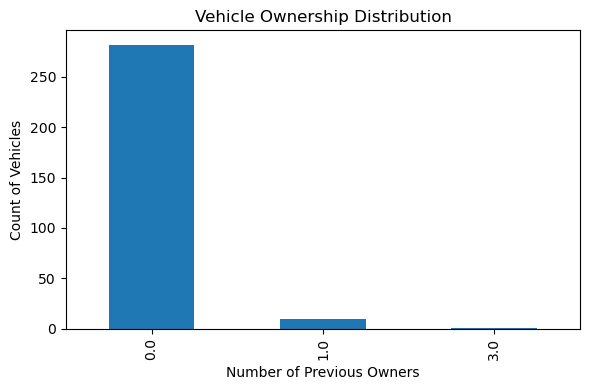

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("car.csv")

# Replace Unknown values
df["Owner"] = pd.to_numeric(df["Owner"], errors="coerce")
df["Owner"].fillna(df["Owner"].mode()[0], inplace=True)

# Count owners
owner_counts = df["Owner"].value_counts().sort_index()

# Plot
plt.figure(figsize=(6,4))
owner_counts.plot(kind="bar")

plt.title("Vehicle Ownership Distribution")
plt.xlabel("Number of Previous Owners")
plt.ylabel("Count of Vehicles")

plt.tight_layout()

plt.savefig("owner_distribution.png")
plt.show()